In [1]:
# Download the Dataset

!wget -O input.txt https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

--2026-06-05 09:32:18--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt’

input.txt           100%[===================>]   1.06M  --.-KB/s    in 0.03s   

2026-06-05 09:32:19 (32.5 MB/s) - ‘input.txt’ saved [1115394/1115394]



In [2]:
# Imports

import numpy as np
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.models import Model

In [3]:
# Loading Dataset

with open("input.txt", "r", encoding="utf-8") as f:
    text = f.read()

print("Dataset length:", len(text))
print("\nFirst 500 characters:\n")
print(text[:500])

Dataset length: 1115394

First 500 characters:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [4]:
# Create Vocabulary

chars = sorted(list(set(text)))

vocab_size = len(chars)

print("Vocabulary Size:", vocab_size)

char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

Vocabulary Size: 65


In [5]:
# Encode Text

encoded = np.array([char_to_idx[c] for c in text])

print(encoded[:20])

[18 47 56 57 58  1 15 47 58 47 64 43 52 10  0 14 43 44 53 56]


In [6]:
# Create Training Sequences

SEQ_LEN = 100
BATCH_SIZE = 64
BUFFER_SIZE = 10000

x = []
y = []

for i in range(len(encoded) - SEQ_LEN):
    x.append(encoded[i:i+SEQ_LEN])
    y.append(encoded[i+1:i+SEQ_LEN+1])

x = np.array(x)
y = np.array(y)

print("Input shape:", x.shape)
print("Target shape:", y.shape)

dataset = tf.data.Dataset.from_tensor_slices((x, y))

# Shuffle, batch, and split
DATASET_SIZE = len(x)
TRAIN_SIZE_SAMPLES = int(0.9 * DATASET_SIZE)

shuffled_dataset = dataset.shuffle(BUFFER_SIZE)
batched_dataset = shuffled_dataset.batch(BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

# Calculate the number of batches for training
TRAIN_SIZE_BATCHES = TRAIN_SIZE_SAMPLES // BATCH_SIZE

train_dataset = batched_dataset.take(TRAIN_SIZE_BATCHES)
val_dataset = batched_dataset.skip(TRAIN_SIZE_BATCHES)

print("Train dataset batch count:", tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation dataset batch count:", tf.data.experimental.cardinality(val_dataset).numpy())

Input shape: (1115294, 100)
Target shape: (1115294, 100)
Train dataset batch count: 15683
Validation dataset batch count: 1743


In [7]:
# Positional Embedding Layer

class TokenAndPositionEmbedding(layers.Layer):

    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()

        self.token_emb = layers.Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim
        )

        self.pos_emb = layers.Embedding(
            input_dim=maxlen,
            output_dim=embed_dim
        )

    def call(self, x):

        positions = tf.range(
            start=0,
            limit=tf.shape(x)[-1]
        )

        positions = self.pos_emb(positions)

        x = self.token_emb(x)

        return x + positions

In [8]:
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.2):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim)
        ])
        self.layernorm1 = layers.LayerNormalization()
        self.layernorm2 = layers.LayerNormalization()
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs, use_causal_mask=True)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

In [9]:
# Build Mini GPT

EMBED_DIM = 128
NUM_HEADS = 4
FF_DIM = 512

inputs = layers.Input(shape=(SEQ_LEN,))

embedding_layer = TokenAndPositionEmbedding(
    SEQ_LEN,
    vocab_size,
    EMBED_DIM
)

x_embed = embedding_layer(inputs)

transformer_block = TransformerBlock(
    EMBED_DIM,
    NUM_HEADS,
    FF_DIM
)

x_processed = transformer_block(x_embed)

outputs = layers.Dense(
    vocab_size,
    activation="softmax"
)(x_processed)

model = Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, 100, 128)       │        21,120 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 100, 128)       │       396,032 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100, 65)        │         8,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 425,537 (1.62 MB)

 Trainable params: 425,537 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=val_dataset
)

Epoch 1/30
15683/15683 ━━━━━━━━━━━━━━━━━━━━ 217s 13ms/step - accuracy: 0.5728 - loss: 1.3764 - val_accuracy: 0.4963 - val_loss: 1.9059
Epoch 2/30
15683/15683 ━━━━━━━━━━━━━━━━━━━━ 207s 13ms/step - accuracy: 0.5963 - loss: 1.2914 - val_accuracy: 0.4998 - val_loss: 1.8897
Epoch 3/30
15683/15683 ━━━━━━━━━━━━━━━━━━━━ 207s 13ms/step - accuracy: 0.5984 - loss: 1.2841 - val_accuracy: 0.5020 - val_loss: 1.8940
Epoch 4/30
15683/15683 ━━━━━━━━━━━━━━━━━━━━ 205s 13ms/step - accuracy: 0.5994 - loss: 1.2801 - val_accuracy: 0.5047 - val_loss: 1.8674
Epoch 5/30
15683/15683 ━━━━━━━━━━━━━━━━━━━━ 206s 13ms/step - accuracy: 0.6006 - loss: 1.2762 - val_accuracy: 0.5064 - val_loss: 1.8651
Epoch 6/30
15683/15683 ━━━━━━━━━━━━━━━━━━━━ 262s 13ms/step - accuracy: 0.6005 - loss: 1.2761 - val_accuracy: 0.5047 - val_loss: 1.8677
Epoch 7/30
15683/15683 ━━━━━━━━━━━━━━━━━━━━ 205s 13ms/step - accuracy: 0.6010 - loss: 1.2734 - val_accuracy: 0.5062 - val_loss: 1.8677
Epoch 8/30
15683/15683 ━━━━━━━━━━━━━━━━━━━━ 205s 13ms/s

In [11]:
model.save("mini_gpt_shakespeare.keras")

In [15]:
import numpy as np

def generate_text(
    model,
    start_string,
    length=500,
    temperature=0.8
):

    input_eval = [char_to_idx[c] for c in start_string]
    generated = start_string

    for _ in range(length):

        input_seq = input_eval[-SEQ_LEN:]

        if len(input_seq) < SEQ_LEN:
            input_seq = [0] * (SEQ_LEN - len(input_seq)) + input_seq

        input_seq = np.array([input_seq])

        predictions = model.predict(
            input_seq,
            verbose=0
        )

        preds = predictions[0, -1]

        # Temperature Sampling
        preds = np.asarray(preds).astype("float64")
        preds = np.log(preds + 1e-8) / temperature
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)

        predicted_id = np.random.choice(
            len(preds),
            p=preds
        )

        generated += idx_to_char[predicted_id]
        input_eval.append(predicted_id)

    return generated

In [17]:
print("=" * 50)

print("Model Statistics")

print("=" * 50)

print(f"Total Parameters: {model.count_params():,}")

print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")

print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")

if 'val_loss' in history.history:
    print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")

if 'val_accuracy' in history.history:
    print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

print("=" * 50)

Model Statistics
Total Parameters: 425,537
Final Training Loss: 1.2665
Final Training Accuracy: 0.6026
Final Validation Loss: 1.8182
Final Validation Accuracy: 0.5117


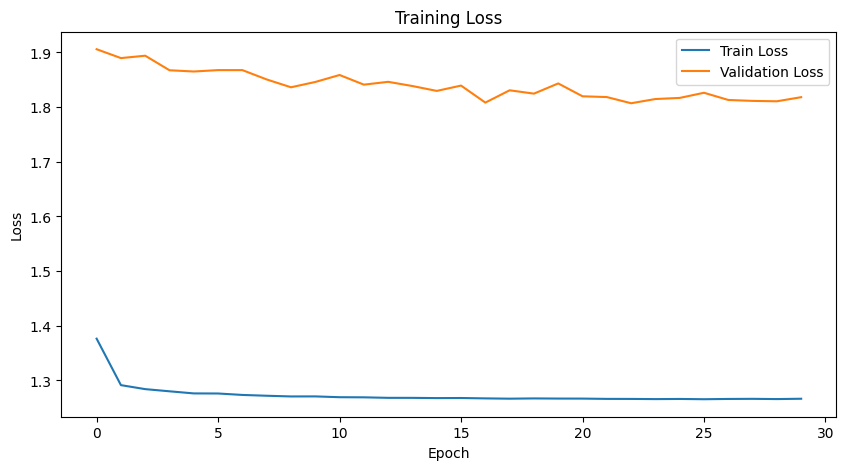

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')

if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()

In [23]:
for temp in [0.6, 0.8, 1.0, 1.2]:
    print("\n" + "="*80)
    print(f"TEMPERATURE = {temp}")
    print("="*80)

    print(
        generate_text(
            model,
            "ROMEO:",
            length=350,
            temperature=temp
        )
    )


TEMPERATURE = 0.6
ROMEO:Lhe she beholding streat me in allow to this is best:
And with a due the not of all.

HORTENSIO:
And, but so be this is gatient.

PETRUCHIO:
I know the rever me underer
That weakness the may goood ever him they content come.

PETRUCHIO:
O, sir, I am such a gentleman,
I have her welcome acccept her with you seee
'Redied to the come a put to my fathe

TEMPERATURE = 0.8
ROMEO:Thile,ing speech your lead for a be so.

PETRUCHIO:
Why, tet house, if you moveilsty do will blow the pitch?

PETRUCHIO:
When alit, let his bear man a cause well.

BAPTISTA:
You are you shall you wimself, and my father,
And so she come I do joce, to of you
have musicsed a best the with the duty begun.

BAPTISTA:
Hortensio loves she's you,
Uncased n

TEMPERATURE = 1.0
ROMEO:Thile,e Seech you are she with I be musics;
Yet known when I do well: but remends.

PETRUCHIO:
Well, I promises, Ked justice to a mannno more is the rough to me,
As of both we gooodst judgice;
Why, calt the else you like, i